# **Projet : Prédiction du nutriscore**
**Module : Machine Learning**


**Groupe : Ameth SYLLA & Ziyad BERJAN**


**Professeur : Dr Nicola ROCHET**

**Établissement : Aix Ynov Campus**


**Date : Mai 2026**


# **Introduction**
Le **Nutri-Score** est devenu un outil de santé publique incontournable en Europe. Ce système d'étiquetage nutritionnel, basé sur un logo allant du vert (A) au rouge (E), a pour but de fournir aux consommateurs une information lisible et rapide sur la qualité nutritionnelle des produits. En calculant un score qui pondère les nutriments à favoriser (fibres, protéines, fruits et légumes) et ceux à limiter (calories, acides gras saturés, sucres, sel), il joue un rôle crucial dans la prévention des maladies liées à l'alimentation et incite les industriels à améliorer leurs recettes.

Pour mener à bien ce projet de modélisation, nous nous appuyons sur la base de données **OpenFoodFacts**. Véritable "Wikipédia de l'alimentation", ce projet collaboratif open data contient des informations sur plus de 4 millions de produits à travers le monde. Son dataset est extrêmement riche : il regroupe des informations d'identité (nom, marque), des données taxonomiques (catégories) ainsi que des compositions nutritionnelles détaillées pour chaque produit, offrant ainsi une base d'apprentissage massive pour le Machine Learning.

L'**objectif principal** de notre étude est de développer un modèle prédictif capable d'estimer avec précision le Nutri-Score d'un produit alimentaire en utilisant exclusivement ses informations nutritionnelles. Une telle solution permettrait, par exemple, d'estimer la qualité d'un nouveau produit en cours de formulation ou de combler les lacunes d'étiquetage sur certains marchés.

Notre **approche technique** se distingue par l'exploitation des deux indicateurs présents dans le dataset d'OpenFoodFacts :
- **Nutri-Score Score (Valeur numérique) :** Cette colonne représente le résultat brut du calcul algorithmique (généralement compris entre -15 et +40). Nous l'utilisons pour une approche par **régression**, visant une précision fine de la valeur continue.
- **Nutri-Score Grade (Catégorie) :** Cette colonne représente la lettre finale (A, B, C, D ou E). Elle est utilisée pour une approche par **classification**.

En travaillant sur ces deux axes, nous serons en mesure de confronter nos résultats : d'un côté la prédiction d'une valeur précise, et de l'autre la classification dans une catégorie, afin de déterminer quelle méthode offre la meilleure fiabilité pour l'évaluation nutritionnelle automatisée.

## **Plan Général**
 ### **I. Approche par Régression**  
 **I.1. Analyse Exploratoire**  
 **I.1.1. Chargement du dataset**  
 **I.1.2. Analyse des valeurs manquantes**  
 **I.1.3. Analyse des outliers**  
 **I.2. Pipline de nettoyage**  
  **I.2.1. Gestion des outliers**  
 **I.2.2. Imputation des valaeurs manquantes**  
  **I.2.3. Elimination des doublons**  
 **I.3. Modélisation et Optimisation**  
 **I.3.1. Baseline Random Forest**  
 **I.3.2. Optimisation avec Optuna**  


-------

### **II. Approche par Classification**  
    Cette partie est dédiée à la prédiction de la catégorie qualitative `nutriscore_grade` (A, B, C, D, E), traitant le problème comme une classification multi-classe.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
from sklearn.model_selection import GridSearchCV
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
import numpy as np





/workspaces/Openfoodfact/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **I.1. Analyse Exploratoire**
Cette phase initiale est cruciale pour appréhender la structure du dataset OpenFoodFacts, qui présente un volume massif de plus de 4,4 millions de lignes pour 210 colonnes. L’objectif est de parcourir les données, de les comprendre afin de pouvoir decider de la stratégie de traitement à appliquer.

#### **I.1.1. Chargement du dataset**  
La première étape consiste à charger un échantillon de 100 000 lignes directement depuis la source compressée d'OpenFoodFacts. Ce premier aperçu permet de constater la complexité du jeu de données brut, qui comporte initialement plus de 200 colonnes incluant des informations très diverses (données logistiques, URLs d'images, indicateurs de packaging). Ce chargement initial sans filtrage de colonnes est essentiel pour observer la structure native du fichier, vérifier les séparateurs de texte et identifier les colonnes contenant un fort taux de données manquantes ou des types de données incohérents avant d'engager une phase de sélection plus stricte.

In [11]:
url = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

raw_df = pd.read_csv(url, sep='\t', low_memory=False, nrows=100000)
raw_df

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,21140182326,http://world-en.openfoodfacts.org/product/0021...,usda-ndb-import,1489078283,2017-03-09T16:51:23Z,1740273873,2025-02-23T01:24:33Z,NaN,1740273873,2025-02-23T01:24:33Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99996,21140187116,http://world-en.openfoodfacts.org/product/0021...,usda-ndb-import,1489050485,2017-03-09T09:08:05Z,1740273873,2025-02-23T01:24:33Z,NaN,1740273873,2025-02-23T01:24:33Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99997,21140187123,http://world-en.openfoodfacts.org/product/0021...,usda-ndb-import,1489059214,2017-03-09T11:33:34Z,1627188147,2021-07-25T04:42:27Z,teolemon,1734763209,2024-12-21T06:40:09Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99998,21140187130,http://world-en.openfoodfacts.org/product/0021...,usda-ndb-import,1489059215,2017-03-09T11:33:35Z,1740273874,2025-02-23T01:24:34Z,NaN,1740273874,2025-02-23T01:24:34Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Afin d'optimiser l'efficacité du modèle et de réduire la complexité computationnelle, une sélection ciblée des variables a été opérée parmi les 210 colonnes disponibles. Ce sous-ensemble se divise en trois catégories : les variables explicatives (features), comprenant les huit nutriments fondamentaux dont les teneurs pour 100g impactent directement le calcul biologique du score (énergie, graisses totales et saturées, sucres, fibres, protéines, glucides et sel) ; la variable cible (target), le nutriscore_score ; et enfin la colonne product_name, conservée spécifiquement pour permettre des analyses sémantiques ultérieures sur la nomenclature des produits

In [5]:
# les colonnes qui vont nous interesser
nutri_cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g', 
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g',
    'salt_100g'
]

identity_cols = ['product_name', 'nutriscore_grade']

target = ['nutriscore_score']

cols = nutri_cols + target + identity_cols

**Chargement itératif par blocs (Chunking)**


Pour traiter efficacement le volume massif de données sans dépasser les capacités de la mémoire vive, une stratégie de chargement par blocs (chunking) a été mise en œuvre à l'aide de l'itérateur reader de Pandas. En fixant un chunksize à 100 000 lignes, le dataset est fractionné en segments gérables, permettant d'appliquer les opérations de filtrage et de nettoyage de manière séquentielle. L'utilisation de l'indice d'itération i offre une flexibilité totale, permettant d'interrompre le processus à n'importe quel bloc (par exemple, après le traitement de 300 000 lignes) pour valider la logique de la pipeline avant un déploiement global. Une fois les blocs extraits et pré-nettoyés, ils sont agrégés via pd.concat pour former un DataFrame de travail cohérent et optimisé, ne contenant que les colonnes préalablement sélectionnées.

In [13]:
reader = pd.read_csv(
        url, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=100000,
        low_memory=False, usecols=cols
    )

chunks = []
for i, chunk in enumerate(reader):
    print(f"Traitement du bloc n°{i} (lignes {i*reader.chunksize} à {(i+1)*reader.chunksize})")
    chunks.append(chunk)
    if i == 2: 
        break

df = pd.concat(chunks)
df


Traitement du bloc n°0 (lignes 0 à 100000)
Traitement du bloc n°1 (lignes 100000 à 200000)
Traitement du bloc n°2 (lignes 200000 à 300000)


,product_name,nutriscore_score,nutriscore_grade,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,Limonade artisanale a la rose,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Chocolate n3,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pâte de fruits,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Paleta gran reserva - Sierra nevada-,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
299995,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
299996,Key Lime Pie Ice Cream,NaN,unknown,1010.106383,12.765957,6.382979,28.191489,17.553191,0.531915,3.191489,0.126330
299997,BARRES DE YOGOURT GLACÉ,NaN,unknown,538.750000,2.500000,1.250000,22.500000,17.500000,0.000000,3.750000,0.140625
299998,Yogourt Glacé Framboises Et Chocolat,11.0,d,766.250000,7.500000,4.375000,25.000000,20.000000,0.000000,3.750000,0.140625


#### **I.1.2. Analyse des valeurs manquantes**  


Une fois le jeu de données restreint chargé, une analyse statistique de la parcimonie (sparsity) est effectuée pour quantifier la proportion de valeurs manquantes (NaN) au sein des colonnes sélectionnées. Cette étape est réalisée via la fonction plot_missing_values, qui calcule le pourcentage de vide par variable et génère une visualisation sous forme de diagramme à barres pour toutes les colonnes dépassant un seuil critique (fixé ici à 2 %). Cette analyse est déterminante pour valider la qualité du signal nutritionnel disponible : elle permet d'identifier les nutriments qui, par leur faible taux de remplissage, pourraient introduire un biais significatif dans le modèle de régression. Les résultats obtenus ici guident directement le choix de la stratégie d'imputation ultérieure, visant à arbitrer entre la suppression des lignes incomplètes et le remplacement des valeurs manquantes par des zéros.


In [36]:
def plot_missing_values(df, threshold=2):
    """
    Calcule et affiche le pourcentage de NaNs par colonne au-delà d'un seuil.
    """
    # Calcul des pourcentages
    percent_missing = df.isnull().sum() * 100 / len(df)
    
    # Filtrage selon le seuil
    filtered = percent_missing[percent_missing > threshold].sort_values(ascending=False)
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=filtered.values, y=filtered.index, hue=filtered.index, palette='viridis', legend=False)
    
    ax.set_title(f"Colonnes avec > {threshold}% de valeurs manquantes des {len(df)} premieres lignes")
    ax.set_xlabel("Pourcentage de NaNs (%)")
    plt.tight_layout()
    
    return ax

<Axes: title={'center': 'Colonnes avec > 2% de valeurs manquantes des 300000 premieres lignes'}, xlabel='Pourcentage de NaNs (%)', ylabel='None'>

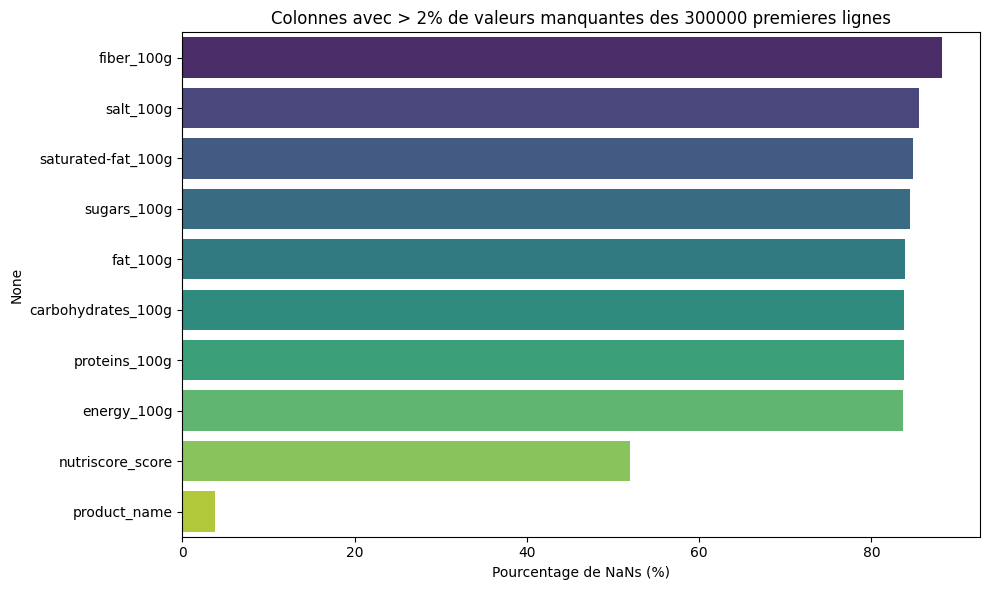

In [37]:
plot_missing_values(df)

L'analyse visuelle de la complétude sur les 300 000 premières lignes révèle une **parcimonie extrême** des données nutritionnelles. Les points clés de cette analyse sont les suivants :

*   **Variables nutritionnelles critiques :** La quasi-totalité des colonnes de nutriments (`fiber_100g`, `salt_100g`, `fat_100g`, etc.) affiche un taux de valeurs manquantes alarmant, oscillant entre **82 % et près de 90 %**. Cela signifie que moins de deux produits sur dix disposent d'informations nutritionnelles complètes dans ce segment initial.
*   **Variable cible (`nutriscore_score`) :** Environ **52 %** des lignes ne possèdent pas de Nutri-Score renseigné. Cette lacune est critique car elle limite directement le volume de données disponibles pour l'entraînement d'un modèle supervisé.
*   **Variable d'identité (`product_name`) :** C'est la colonne la mieux renseignée avec seulement **4 %** de valeurs manquantes, confirmant son utilité pour le suivi des produits.

Ce constat impose un arbitrage. Une suppression pure et simple des lignes contenant des `NaN` réduirait le dataset à un volume trop faible pour une première itération. Par conséquent, une stratégie d'**imputation par zéro** pour les nutriments est adoptée afin de préserver la masse de données, tout en étant conscient du bruit important que cela introduira dans le modèle.

#### **I.1.3. Analyse des outliers**  

la fonction plot_outlier utilise des boxplots pour identifier visuellement les données s'écartant de manière irréaliste des normes physiques.

Afin de gérer l'hétérogénéité des échelles, une échelle logarithmique est spécifiquement appliquée à la variable energy_100g pour compenser des écarts extrêmes constatés dans les données brutes, où certaines valeurs dépassent largement les limites biologiques. Cette visualisation permet de confirmer la pertinence des futurs seuils de filtrage (ex: plafonnement à 100g pour les nutriments) en mettant en évidence les points de données qui pollueraient l'apprentissage de la régression.

In [ ]:
def plot_outlier(df_clean):        
    n_cols = 3
    n_rows = math.ceil(len(nutri_cols) / n_cols)

    plt.figure(figsize=(15, 5 * n_rows))

    for i, nut in enumerate(nutri_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(y=nut, data=df_clean, palette='Set2')
        plt.title(f'Distribution de {nut}')
        
        # Échelle logarithmique pour l'énergie car les écarts sont extrêmes
        if nut == 'energy_100g':
            plt.yscale('log')
        
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

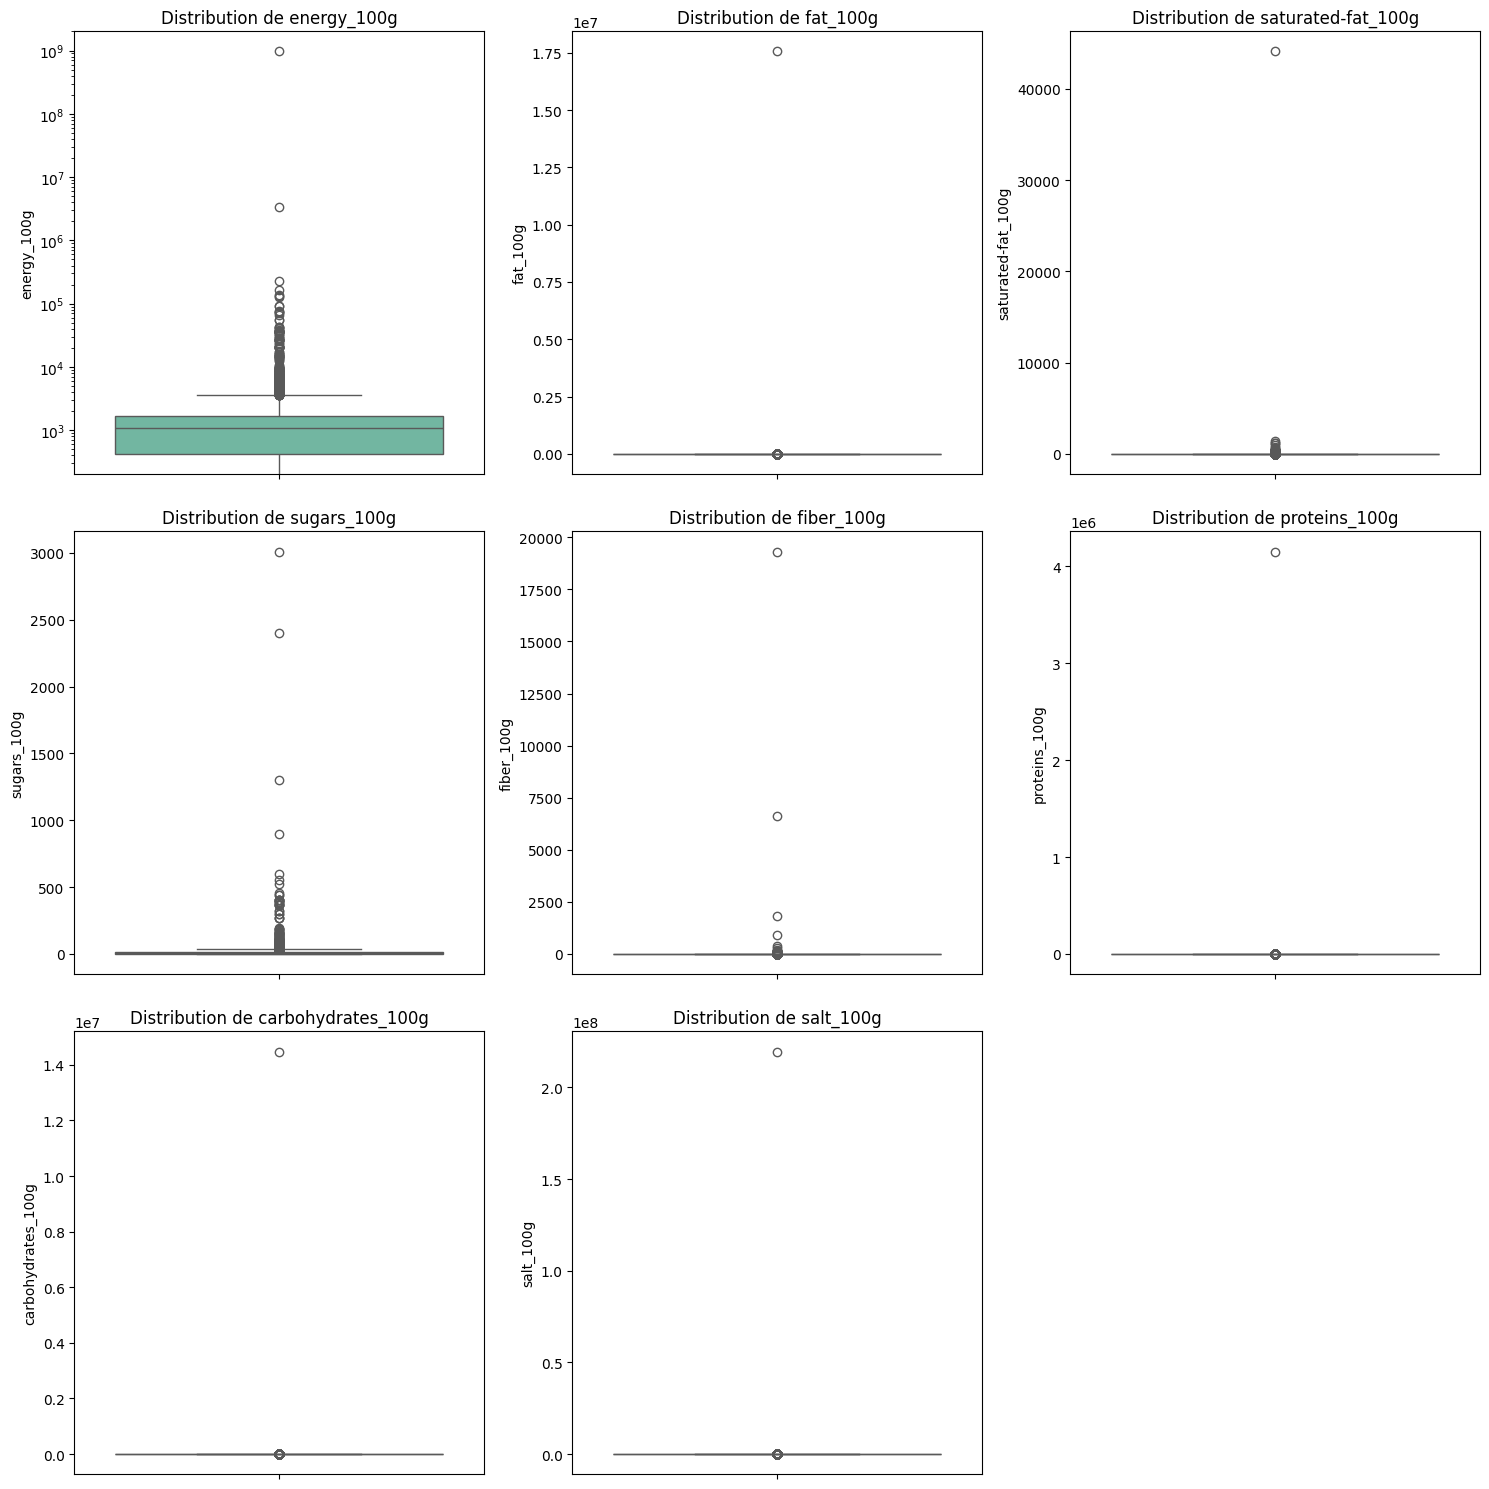

In [38]:
plot_outlier(df)

L'examen visuel des variables nutritionnelles met en évidence des anomalies majeures :
*   **Énergie (`energy_100g`) :** Même avec une échelle logarithmique, on observe des points atteignant **10⁹ kJ**. À titre de comparaison, la valeur énergétique maximale physiquement possible (pure graisse) est d'environ 3 700 kJ pour 100g.
*   **Nutriments (g/100g) :** Les variables comme `fat_100g`, `carbohydrates_100g` ou `salt_100g` présentent des valeurs s'élevant à **10⁷** ou **10⁸**. Or, la somme de tous les nutriments ne peut excéder la masse totale du produit, soit **100g**.
*   **Impact sur la boîte :** La présence de ces "méga-outliers" écrase complètement les boîtes à moustaches au bas de l'axe des ordonnées, rendant la médiane et les quartiles invisibles à l'œil nu sur une échelle linéaire.

Face à ces erreurs de saisie manifestes, des filtres de nettoyage seront instaurés pour garantir l'intégrité physique des données


### **I.1. Pipline de nettoyage**

Le traitement des données repose sur la mise en place d'un enchainement d'action ecapsule dans la fonction `clean_df`. Cette étape transforme les observations issues de l'analyse exploratoire en règles de gestion systématiques afin d'assainir le jeu de données final. La pipeline s'articule autour de trois axes correctifs : une gestion des outliers par l'application de filtres de réalisme physique sur les nutriments et l'énergie, une imputation des valeurs manquantes visant à substituer les données lacunaires par des constantes déterminées, et une élimination des doublons.

**I.2.1. Gestion des outliers**  
La détection des valeurs aberrantes s'appuie sur des contraintes biologiques et physiques strictes afin d'éliminer le bruit généré par les erreurs de saisie manuelle dans OpenFoodFacts. Pour les variables nutritionnelles (masses), un filtre est appliqué pour ne conserver que les valeurs comprises entre 0 et 100g pour 100g de produit. Concernant la densité énergétique, le seuil maximal est fixé à 4000 kJ, excluant ainsi les valeurs physiquement impossibles tout en préservant les produits à forte teneur lipidique. Enfin, la variable cible nutriscore_score est filtrée pour respecter l'échelle légale allant de -15 à +40. Cette étape garantit que le modèle de régression s'entraîne sur des relations nutritionnelles cohérentes.


**I.2.2. Imputation des valaeurs manquantes**  
Dans cette première itération, une stratégie d'imputation par zéro a été adoptée pour l'ensemble des colonnes nutritionnelles. Bien que simpliste, ce choix permet de maximiser la taille du jeu de données en évitant la suppression massive de lignes incomplètes révélée lors de l'analyse du vide. Pour la colonne product_name, les valeurs manquantes sont remplacées par le label "Unknown Product" afin de maintenir l'intégrité de la structure du DataFrame sans perdre d'échantillons. Cette approche vise à établir une "baseline" de performance sur un volume de données important avant d'envisager des méthodes d'imputation statistique plus complexes.


**I.2.3. Elimination des doublons**  
L'intégrité du dataset est finalisée par un processus de déduplication systématique. En supprimant les entrées répétées, on évite le sur-apprentissage (overfitting) lié à la présence multiple d'un même échantillon dans le jeu d'entraînement. Cette étape assure que chaque observation contribue de manière unique et équitable à la construction du modèle de forêt aléatoire.




In [14]:
def clean_df(df_raw, target='nutriscore_score'):
    df = df_raw.copy()
    
    # 1. Conversion et nettoyage de la TARGET en INT
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df.dropna(subset=[target])
    df[target] = df[target].astype(int)

    # Filtre de réalisme pour le score cible (-15 à +40)
    df = df[(df[target] >= -15) & (df[target] <= 40)]
    
    # 2. Conversion et filtrage des colonnes nutritionnelles
    for col in nutri_cols:
        if col in df.columns:
            # Conversion en float pour les décimales
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Application des filtres d'outliers (on ne drop pas encore les NaNs ici)
            if col != 'energy_100g':
                # On garde les valeurs valides (0-100) OU les NaNs pour imputation ultérieure
                df = df[(df[col].isna()) | ((df[col] >= 0) & (df[col] <= 100))]
            else:
                # Filtre spécifique énergie < 4000 kJ[cite: 2]
                df = df[(df[col].isna()) | ((df[col] >= 0) & (df[col] < 4000))]

    # Conversion, suppression des NaNs et passage en entier pour la TARGET
    df[target] = pd.to_numeric(df[target], errors='coerce')
    df = df.dropna(subset=[target])
    df[target] = df[target].astype(int) 
    
    # 3. Traitement spécifique de 'product_name' si présent
    if 'product_name' in df.columns:
        df['product_name'] = df['product_name'].fillna('Unknown Product')

    # 4. Imputation finale des valeurs manquantes par 0 pour les colonnes numériques
    # On cible uniquement les colonnes nutritionnelles présentes
    cols_to_fix = [c for c in nutri_cols if c in df.columns]
    df[cols_to_fix] = df[cols_to_fix].fillna(0)
        
    return df

In [ ]:
def process_full_dataset(url, cols, chunk_size=100000):
    reader = pd.read_csv(
        url, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=chunk_size,
        low_memory=False, usecols=cols
    )
    
    clean_chunks = []
    print("Début du traitement des données par blocs...")

    for i, chunk in enumerate(reader):
        # 1. Nettoyage des valeurs aberrantes
        # On passe explicitement le nom de la cible
        chunk_clean= clean_df(chunk, target='nutriscore_score')
        
        clean_chunks.append(chunk_clean)
        
        if i % 5 == 0:
            print(f"Bloc {i} terminé. Taille actuelle cumulée : {sum(len(c) for c in clean_chunks)}")

    print("Fusion des blocs en cours...")
    df_final = pd.concat(clean_chunks, ignore_index=True)

    count = df_final.duplicated().sum()
    print(f"Nombre de doublons détectés : {count}")
    df_final.drop_duplicates()
    
    print("-" * 30)
    print(f"Traitement terminé avec succès. Lignes finales : {len(df_final)}")
    
    return df_final

In [19]:
df_cleaned = process_full_dataset(url, cols)

Début du traitement des données par blocs...
Bloc 0 terminé. Taille actuelle cumulée : 45049
Bloc 5 terminé. Taille actuelle cumulée : 255190
Bloc 10 terminé. Taille actuelle cumulée : 365970
Bloc 15 terminé. Taille actuelle cumulée : 486696
Bloc 20 terminé. Taille actuelle cumulée : 716642
Bloc 25 terminé. Taille actuelle cumulée : 862443
Bloc 30 terminé. Taille actuelle cumulée : 986633
Bloc 35 terminé. Taille actuelle cumulée : 1098784
Bloc 40 terminé. Taille actuelle cumulée : 1275778
Fusion des blocs en cours...
Nombre de doublons détectés : 137542
------------------------------
Traitement terminé avec succès. Lignes finales : 1362019


In [21]:
df_cleaned

,product_name,nutriscore_score,nutriscore_grade,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,granola Bio le Chocolaté,4,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,Unknown Product,6,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2,xytitol pastilles,-11,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,Powdered peanut butter,3,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,Madeleines ChocoLait,20,e,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
1362014,Erdbeerkuchen 1019g tiefgefroren,13,d,925.0,7.6,4.8,35.0,24.0,0.0,2.6,0.28
1362015,Steak haché 5%,1,b,550.5,5.0,2.3,0.0,0.0,0.0,21.5,0.18
1362016,Beurre de cacahuète bio,-9,a,2738.7,51.0,6.4,16.3,0.0,8.5,29.8,0.40
1362017,Unknown Product,4,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


In [22]:

df_cleaned.to_csv('../data/01_openfoodfacts_clean.csv', index=False)


In [53]:
print(df_cleaned.isna().sum())

product_name          0
nutriscore_score      0
energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
dtype: int64


/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=nut, data=df_clean, palette='Set2')
/tmp/ipykernel_40525/3386449001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

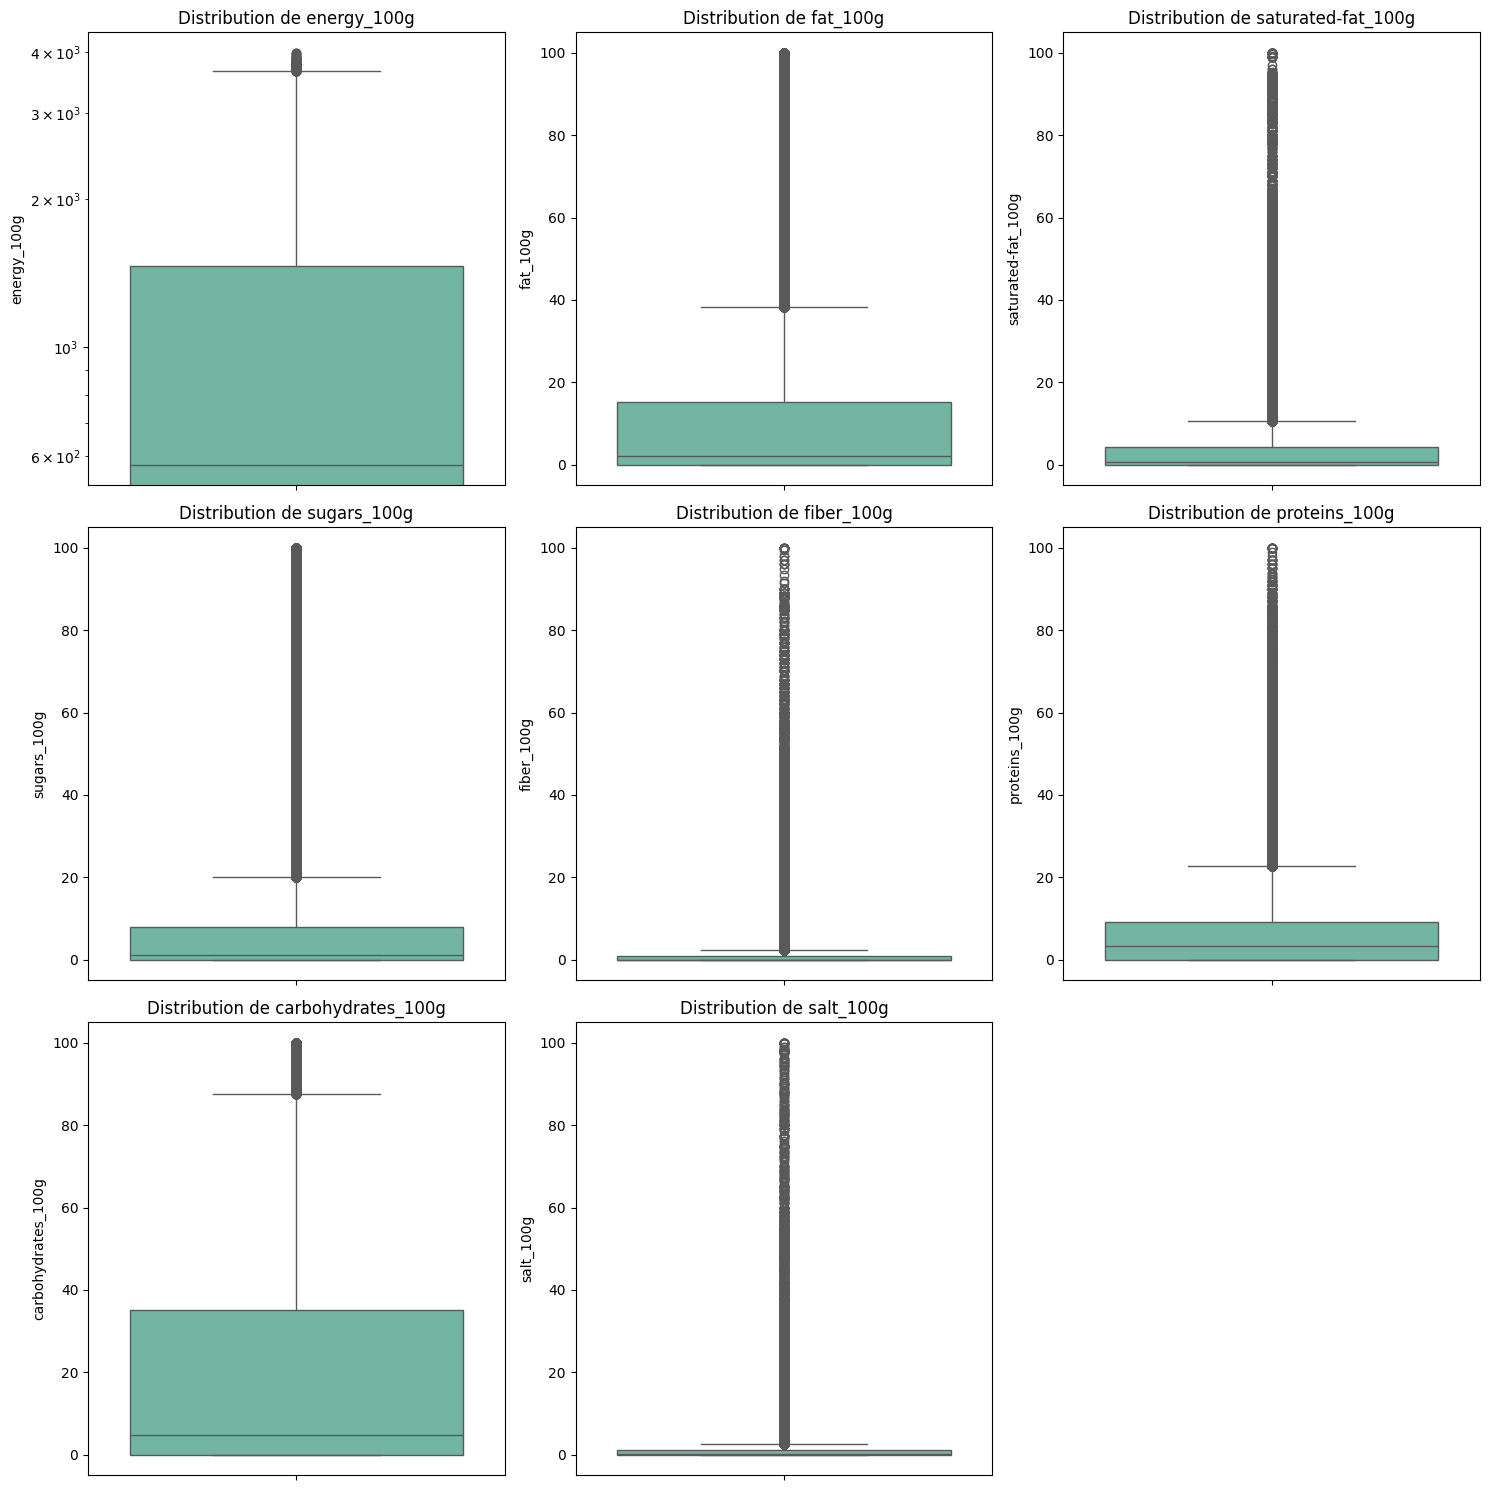

In [54]:
plot_outlier(df_cleaned)


Contrairement aux visualisations initiales, les distributions sont désormais contenues dans des limites physiquement cohérentes, ce qui assainit le signal pour le futur modèle :

*   **Respect des limites physiques :** Toutes les variables de masse (`fat_100g`, `sugars_100g`, `proteins_100g`, etc.) sont strictement comprises dans l'intervalle $[0, 100]$. L'énergie (`energy_100g`) est plafonnée à **4000 kJ**, éliminant les valeurs aberrantes à $10^9$ qui écrasaient la distribution précédemment.
*   **Visibilité des structures statistiques :** L'élimination des "méga-outliers" permet enfin d'observer la boîte centrale (représentant l'intervalle interquartile) et la médiane pour chaque nutriment. On note que la médiane de plusieurs variables se situe proche de zéro, ce qui reflète l'impact de la stratégie d'**imputation par zéro** choisie pour cette itération.
*   **Présence d'outliers "réalistes" :** Bien que des points isolés subsistent en haut des moustaches (notamment pour les fibres ou le sel), ils ne sont plus aberrants au sens physique du terme (ex: produits extrêmement salés). Le modèle de **Random Forest**, par sa nature robuste, sera capable de traiter ces valeurs extrêmes réelles sans perte de performance.

Cette étape de validation confirme que les données ont été correctement "normalisées" aux limites du monde physique, offrant une base acceptable pour la phase de modélisation.


In [3]:
df_cleaned = pd.read_csv(
        "../data/01_openfoodfacts_clean.csv", sep=',',
        on_bad_lines='skip',
        low_memory=False
    )

In [26]:
df_cleaned

,product_name,nutriscore_score,nutriscore_grade,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,granola Bio le Chocolaté,4,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
1,Unknown Product,6,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2,xytitol pastilles,-11,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,Powdered peanut butter,3,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,Madeleines ChocoLait,20,e,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
1362014,Erdbeerkuchen 1019g tiefgefroren,13,d,925.0,7.6,4.8,35.0,24.0,0.0,2.6,0.28
1362015,Steak haché 5%,1,b,550.5,5.0,2.3,0.0,0.0,0.0,21.5,0.18
1362016,Beurre de cacahuète bio,-9,a,2738.7,51.0,6.4,16.3,0.0,8.5,29.8,0.40
1362017,Unknown Product,4,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


/tmp/ipykernel_2330/1078328261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='nb_nutriments_reels', data=df_cleaned, palette='viridis')


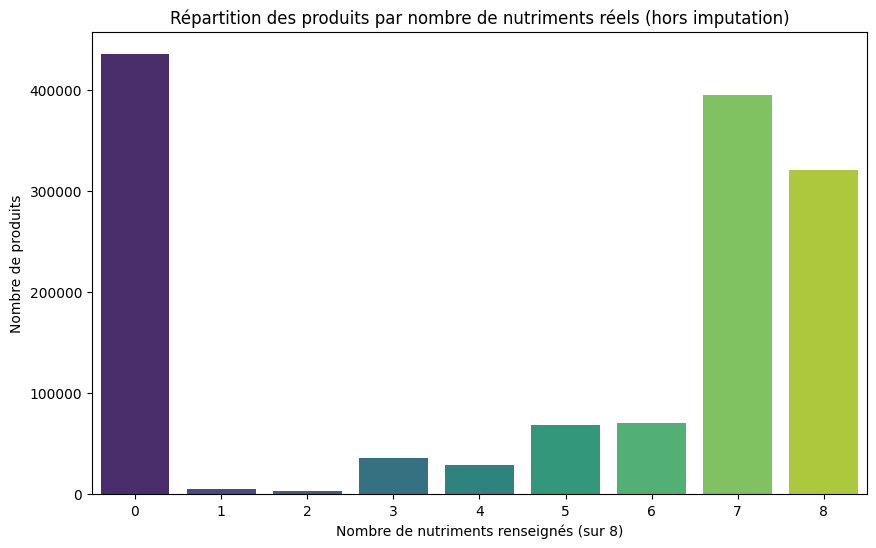

### **I.3. Modélisation et Optimisation**  


La phase finale de cette première itération consiste à transformer les données nettoyées en un modèle prédictif capable d'estimer le Nutri-Score à partir de la composition nutritionnelle. Cette étape s'articule autour de deux jalons complémentaires : l'établissement d'une Baseline Random Forest, visant à évaluer les performances initiales de l'algorithme de forêt aléatoire avec ses paramètres par défaut sur un dataset de masse, et une phase d'optimisation avec Optuna. Ce framework d'optimisation bayésienne est utilisé pour explorer de manière automatisée et efficace l'espace des hyperparamètres, afin de minimiser l'erreur absolue moyenne (MAE) et de maximiser la capacité de généralisation du régresseur face au bruit introduit par l'imputation par zéro.



L'implémentation du modèle débute par la séparation des données en variables explicatives ($X$), regroupant les 8 nutriments clés, et en variable cible ($y$), le nutriscore_score. Afin d'évaluer la capacité du modèle à généraliser sur des données inconnues, le dataset nettoyé est divisé en deux ensembles : 80 % pour l'entraînement et 20 % pour le test, en fixant un random_state à 42 pour garantir la reproductibilité des résultats.

In [6]:
# On ne garde que les nutriments pour prédire
X = df_cleaned[nutri_cols]
# cible
y = df_cleaned['nutriscore_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entraînement sur : {X_train.shape[0]} lignes")
print(f"Test sur : {X_test.shape[0]} lignes")

Entraînement sur : 1089615 lignes
Test sur : 272404 lignes


**I.3.1. Baseline Random Forest**  

#### **I.3.1. Baseline Random Forest**

L'établissement de la référence de performance repose sur l'algorithme **Random Forest Regressor**, une méthode d'apprentissage ensembliste par "bagging" qui construit une multitude d'arbres de décision de manière indépendante durant l'entraînement. La prédiction finale est obtenue en moyennant les résultats de chaque arbre, ce qui permet de réduire significativement la variance du modèle. Ce choix est particulièrement pertinent pour notre dataset post-traitement pour trois raisons majeures :
*   **Robustesse face au bruit** : Bien que notre stratégie d'imputation par zéro ait introduit un bruit non négligeable dans les données, le Random Forest est naturellement résistant aux valeurs aberrantes subsistantes et aux données imputées grâce au sous-échantillonnage aléatoire des variables et des observations.
*   **Captation des non-linéarités** : Le calcul du Nutri-Score n'est pas une simple somme linéaire ; il dépend de seuils et d'interactions complexes entre nutriments "négatifs" (sucres, sel) et "positifs" (fibres, protéines). Les arbres de décision excellent dans la détection de ces paliers et de ces interactions croisées.
*   **Stabilité sur le volume** : Ayant conservé un volume massif de données après nettoyage, cet algorithme est capable de converger vers une solution stable sans nécessiter de normalisation préalable des caractéristiques (features), traitant aussi bien l'énergie en kJ que les nutriments en grammes.

Pour maximiser la précision de notre modèle sur les données, il est essentiel d'ajuster finement les leviers structurels du **Random Forest Regressor**. Les hyperparamètres ciblés jouent des rôles déterminants pour la performance finale :

*   **n_estimators** : Ce paramètre définit le nombre d'arbres dans la forêt ; une valeur élevée stabilise les prédictions et réduit la variance, ce qui est crucial pour lisser le bruit introduit par l'imputation massive de zéros dans nos données nutritionnelles.
*   **max_depth** : Il contrôle la profondeur maximale de chaque arbre. Dans notre contexte, une profondeur suffisante est nécessaire pour capturer les interactions non linéaires entre nutriments (comme l'équilibre entre sucres et fibres), mais elle doit être limitée pour éviter que le modèle n'apprenne par cœur les spécificités de l'échantillon d'entraînement (overfitting).
*   **min_samples_split** : Ce paramètre impose un nombre minimal d'individus pour diviser un nœud interne. Il agit comme un régulateur de complexité, garantissant que les règles de décision s'appuient sur un nombre représentatif de produits et non sur des cas isolés ou des erreurs de saisie résiduelles.
*   **max_features** : Il détermine le nombre de nutriments à considérer lors de la recherche de la meilleure division à chaque nœud. En limitant ce nombre, on décorrèle davantage les arbres entre eux, renforçant ainsi la robustesse globale de la forêt face à la redondance potentielle de certaines variables nutritionnelles.

Dans la section qui suit nous utliserons Optuna pour Rechecher les meilleurs valeurs de ces hyperparametres

 **I.3.2. Optimisation avec Optuna** 

L'optimisation des hyperparamètres est réalisée via **Optuna**, un framework d'optimisation bayésienne de pointe qui surpasse les méthodes traditionnelles comme le *GridSearch* ou le *RandomSearch*. Contrairement à une recherche exhaustive (GridSearch), qui explore aveuglément toutes les combinaisons possibles, Optuna utilise un échantillonneur de processus gaussien pour prédire quelles zones de l'espace de recherche sont les plus prometteuses. Cette approche est particulièrement pertinente ici car elle permet d'identifier la configuration optimale beaucoup plus rapidement, économisant ainsi des ressources de calcul précieuses sur notre volumineux jeu de données.

L'implémentation repose sur une fonction `objective` qui définit l'espace de recherche et la métrique à optimiser :
*   **Espace de recherche dynamique** : Le modèle explore des plages d'entiers pour le nombre d'arbres (50 à 200), la profondeur (10 à 30) et les critères de division des nœuds, permettant d'ajuster finement la complexité de la forêt face au bruit des données.
*   **Validation Croisée (CV)** : Pour garantir la robustesse, chaque essai est évalué par une validation croisée en 5 blocs (`cv=5`), ce qui assure que les hyperparamètres sélectionnés ne sont pas sur-ajustés à un sous-ensemble spécifique de l'entraînement.
*   **Critère de performance** : La métrique choisie est la **MAE** (Mean Absolute Error). Comme Optuna cherche à maximiser le résultat, nous utilisons la MAE négative fournie par `cross_val_score`, ce qui revient mathématiquement à minimiser l'erreur de prédiction du Nutri-Score.
*   **Optimisation itérative** : Avec 50 essais (`n_trials=50`), l'algorithme affine ses choix à chaque étape, convergeant vers un équilibre idéal entre biais et variance pour notre régresseur final.

In [ ]:
def objective(trial):
    # Suggestions d'hyperparamètres
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 10, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    
    # Modèle avec les hyperparamètres suggérés
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        n_jobs=-1,
        random_state=42
    )
    
    # Validation croisée (5 folds, MAE négative pour minimiser)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return scores.mean()  # Retourne la MAE moyenne (négative)

In [ ]:
# Création de l'étude Optuna
study = optuna.create_study(direction='maximize')  # Maximise le score négatif MAE
study.optimize(objective, n_trials=50)  # 50 essais

# Meilleurs hyperparamètres
print("Meilleurs hyperparamètres :", study.best_params)
print("Meilleur score CV :", study.best_value)


Meilleurs hyperparamètres : {'n_estimators': 86, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 3}  
Meilleur score CV : -3.459162710059914

**Analyse des résultats de l'optimisation**

L'exécution de l'étude Optuna sur 50 essais a permis d'extraire une configuration optimale pour le modèle, aboutissant à un **Meilleur score CV de -3,46** (en termes de MAE négative). Ces résultats traduisent une précision remarquable du modèle, capable de prédire le Nutri-Score avec une erreur moyenne d'environ **3,5 points** sur une échelle qui en compte 55.

Les hyperparamètres retenus illustrent un arbitrage précis entre complexité et robustesse :
*   **n_estimators (86)** : L'algorithme a convergé vers un nombre d'arbres modéré, suffisant pour stabiliser la variance sans alourdir inutilement le temps d'inférence.
*   **max_depth (25)** : Une profondeur relativement élevée a été privilégiée, confirmant que le modèle nécessite une certaine finesse pour capturer les interactions non linéaires complexes entre les nutriments.
*   **min_samples_leaf (3) & min_samples_split (5)** : Ces valeurs agissent comme des régulateurs, empêchant les arbres de s'isoler sur des cas trop spécifiques (bruit) tout en restant assez flexibles pour modéliser les tendances réelles des données.

Cette phase d'optimisation valide la pertinence de l'approche bayésienne : elle a permis d'affiner le régresseur pour qu'il devienne un outil de prédiction fiable, malgré les défis initiaux liés à la qualité des données brutes.

In [ ]:
# Entraînement du modèle final avec les meilleurs params
best_params = study.best_params
best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
best_model.fit(X_train, y_train)


# Évaluation sur le test set
y_pred_optuna = best_model.predict(X_test)
print(f"Score R² sur test : {r2_score(y_test, y_pred_optuna):.4f}")
print(f"Erreur Moyenne (MAE) sur test : {mean_absolute_error(y_test, y_pred_optuna):.4f} points")


# Sauvegarde du modèle optimisé
joblib.dump(best_model, '../models/01_random_forest_optuna.joblib')
print("Modèle optimisé sauvegardé.")

Score R² sur test : 0.6354  
Erreur Moyenne (MAE) sur test : 3.4209 points

In [14]:
best_params = {'n_estimators': 86, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 3}

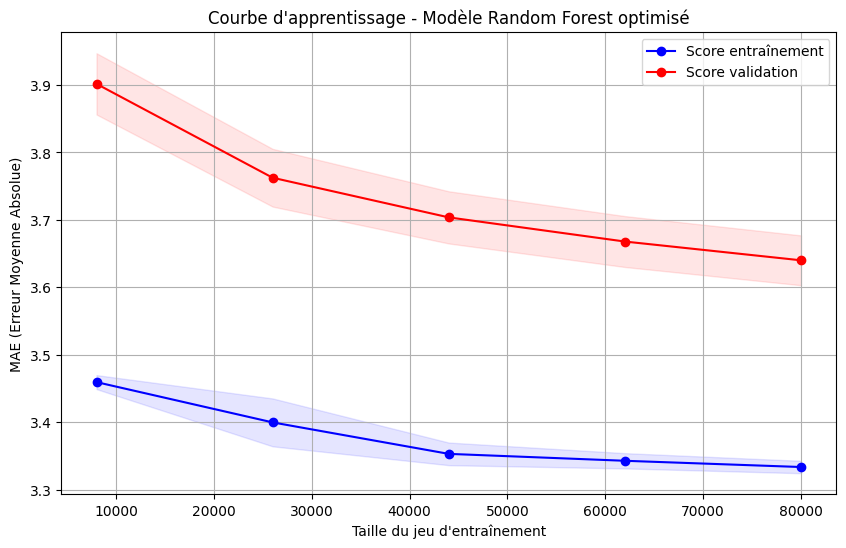

In [ ]:
# Prendre un échantillon de 50k ou 100k lignes (suffisant pour voir la convergence)
X_subset = X_train.sample(100000, random_state=42)
y_subset = y_train.loc[X_subset.index]

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(**best_params, random_state=42),
    X_subset, y_subset, cv=5, 
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=2 # Limite les workers pour éviter le crash RAM
)

# Moyennes et écarts-types
train_scores_mean = -train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
val_scores_mean = -val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

# Tracé
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Score entraînement')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_scores_mean, 'o-', color='red', label='Score validation')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color='red')
plt.title('Courbe d\'apprentissage - Modèle Random Forest optimisé')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('MAE (Erreur Moyenne Absolue)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Avant de figer nos conclusions, l'étude de la courbe d'apprentissage effectuée sur un échantillons de 100 000 lignes est essentielle pour comprendre la relation entre la quantité de données et la performance du modèle. 

Cette courbe confronte l'erreur sur le jeu d'entraînement à l'erreur sur le jeu de validation au fur et à mesure que l'on augmente la taille de l'échantillon.Interprétation de la dynamique d'apprentissageL'analyse de la courbe révèle deux phénomènes majeurs :  

Convergence des scores : On observe que l'erreur de validation diminue avec l'ajout de données, tandis que l'erreur d'entraînement augmente légèrement. Ce rapprochement des deux courbes indique que le modèle bénéficie de l'augmentation du volume de données pour mieux généraliser, réduisant ainsi le risque de sur-apprentissage (overfitting).

Le "Plateau" de performance : La courbe montre une tendance à la stabilisation. L'ajout de données supplémentaires permettra probablement de grappiller quelques fractions de points de MAE, mais la performance plafonnera inévitablement vers le score obtenu lors de notre entraînement final ($MAE \approx 3,42$). Ce plateau suggère que le modèle a extrait le maximum d'informations possible des 8 nutriments fournis.

**Synthèse des résultats et analyse critique des limites**  
Le modèle final, bien qu'optimisé par Optuna, présente un bilan contrasté qui nécessite une lecture critique, particulièrement concernant la structure des données après imputation.

*   **Précision ($R^2 = 0,6354$) :** Le modèle explique **63,5 %** de la variance du Nutri-Score. C'est un résultat notable pour un modèle "baseline", mais cela signifie qu'une part importante de la logique du score échappe encore à l'algorithme.
*   **Marge d'erreur (MAE = 3,42) :** L'erreur moyenne de **3,42 points** reste problématique pour la classification. Un tel écart peut facilement faire basculer un produit d'une catégorie à une autre (par exemple de "A" à "B"), limitant la fiabilité du modèle pour un étiquetage automatique.

Ces limites ne proviennt pas forcement de l'algorithme, mais de la conséquence directe de notre stratégie de nettoyage :

*   **Le poids des "Lignes à Zéro" :** L'analyse du vide a montré que plus de 80 % des données nutritionnelles étaient manquantes. En imputant ces valeurs par **0**, nous avons créé une masse artificielle de produits "vides" qui possèdent pourtant un Nutri-Score réel dans la base.


En choisissant de conserver toutes les lignes où la colonne product_name était renseignée (même si les 8 colonnes nutritionnelles étaient vides), nous avons introduit un volume massif de données "fantômes". Ces produits possèdent une identité textuelle mais aucune substance biologique exploitable pour une régression.  La décision de maintenir les lignes où même le nom était absent (remplacé par "Unknown Product") pour sauver quelques rares lignes aux données nutritionnelles présentes a accentué ce phénomène. En appliquant ensuite une imputation par 0 sur tous les NaN, nous avons créé un dataset où une immense majorité de lignes sont mathématiquement identiques (vecteurs de zéros) tout en étant associées à des Nutri-Scores réels et variés (de A à E).

/tmp/ipykernel_2330/2429430242.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='nb_nutriments_reels', data=df_cleaned, palette='viridis')


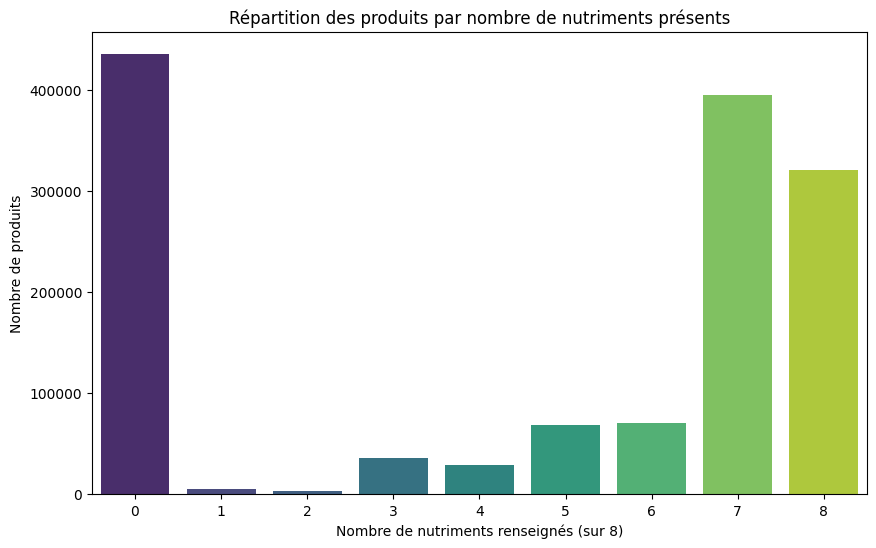

In [24]:
# Compter le nombre de nutriments non nuls par ligne (parmi les 8 nutri_cols)
df_cleaned['nb_nutriments_reels'] = (df_cleaned[nutri_cols] != 0).sum(axis=1)

plt.figure(figsize=(10, 6))
sns.countplot(x='nb_nutriments_reels', data=df_cleaned, palette='viridis')
plt.title('Répartition des produits par nombre de nutriments présents')
plt.xlabel('Nombre de nutriments renseignés (sur 8)')
plt.ylabel('Nombre de produits')
plt.show()

Ce graphique est la preuve visuelle du "plafond de verre" rencontré par le modèle lors de la phase de modélisation. Il révèle une segmentation binaire du dataset qui explique l'instabilité de l'apprentissage.

La barre la plus haute du graphique correspond aux produits ayant zéro nutriment renseigné.

Ce volume massif (plus de 400 000 produits) provient de notre décision de conserver les lignes où seul le product_name était présent ou remplacé par "Unknown Product".

Après imputation par zéro, ces produits deviennent des vecteurs de données strictement identiques. Pourtant, ils possèdent des nutriscore_score réels très différents dans la base. Le modèle se retrouve à devoir prédire des cibles contradictoires pour des entrées identiques, ce qui génère un bruit statistique insurmontable.

On observe un fossé important entre les produits vides et ceux partiellement renseignés. Très peu de produits disposent de seulement 1, 2 ou 3 nutriments.

Les barres situées à droite représentent le véritable signal : les produits ayant 7 ou 8 nutriments renseignés (environ 700 000 produits au total). C'est uniquement sur cette partie du graphique que le Random Forest peut réellement apprendre les corrélations mathématiques du Nutri-Score.

**Conclusion pour l'itération suivante**  
Ce constat graphique impose un changement radical de stratégie pour la suite du projet. Pour améliorer le score $R^2$ et réduire la MAE, pour l'itération suivante, la suppression de la colonne product_name devient une nécessité méthodologique pour assainir l'apprentissage du modèle.